In [ ]:
    for i in range(T):
        if i == 0:
            ll += norm.logpdf(gmsl_data[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            ll += norm.logpdf(gmsl_data[i], loc=rho * gmsl_data[i-1], scale=sigma)


In [ ]:
import numpy as np
from scipy.stats import norm

def ar_loglik(params, temp_obs, temp_err, m):
    S, γ, α, d, D, T₀, ρ, σ = params 
    ebm_sim = m((S, γ, α, d, D, T₀))
    residuals = temp_obs - ebm_sim
    ll = 0
    for t in range(len(temp_err)):
        if t == 0:
            ll += norm.logpdf(residuals[0], loc=0, scale=np.sqrt(σ**2 / (1 - ρ**2) + temp_err[0]**2))
        else:
            resid_wn = residuals[t] - ρ * residuals[t-1]
            ll += norm.logpdf(resid_wn, loc=0, scale=np.sqrt(σ**2 + temp_err[t]**2))
    return ll

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# k is length of block
k = 20
m = int(np.ceil(len(dat['weather']) / k))
n_boot = 1000
weather_bootstrap = np.zeros((len(dat['weather']), n_boot))

for i in range(n_boot):
    block_sample_idx = np.random.choice(range(n_blocks), m, replace=True)
    weather_bootstrap[:, i] = np.concatenate(blocks[:, block_sample_idx])



In [ ]:
boot_freq = salamander_data.sample(n=salamander_data.shape[0], replace=True)
result = minimize(lambda θ: -salaman_model(θ, boot_freq['PCTCOVER'], boot_freq['SALAMAN']), init, bounds=list(zip(lb, ub)))

In [ ]:
result
θ_mle = result.x
print(np.round(θ_mle, decimals=5))

[0.57474 1.08496]


In [ ]:
values = pd.Series([1,2,3,4,5,6,7])

In [ ]:
m

4

In [ ]:
n_blocks

6

In [ ]:
np.ceil(len(values) / k)

np.float64(4.0)

In [ ]:
# k is length of block
k = 2
n_blocks = len(values) - k + 1
blocks = np.zeros([k, n_blocks])
for i in range(n_blocks):
    blocks[:, i] = values[i:(k+i)]

# blocks[:, 1:5]

m = int(np.ceil(len(values) / k))
n_boot = 3
weather_bootstrap = np.zeros((len(values), n_boot))

for i in range(n_boot):
    block_sample_idx = np.random.choice(range(n_blocks), m, replace=True)
    weather_bootstrap[:, i] = np.concatenate(blocks[:, block_sample_idx])

ValueError: could not broadcast input array from shape (8,) into shape (7,)

In [ ]:
block_sample_idx = np.random.choice(range(n_blocks), m, replace=True)
weather_bootstrap[:, i] = np.concatenate(blocks[:, block_sample_idx])[0:len(weather_bootstrap[:, i])]

In [ ]:
weather_bootstrap[:, i]

array([2., 6., 2., 3., 3., 7., 3.])

In [ ]:
np.concatenate(blocks[:, block_sample_idx])[1:len(weather_bootstrap[:, i])]

array([3., 6., 2., 4., 4., 7.])

In [ ]:
pd.DataFrame(blocks)

,0,1,2,3,4,5
0,1.0,2.0,3.0,4.0,5.0,6.0
1,2.0,3.0,4.0,5.0,6.0,7.0


In [ ]:
np.concatenate(blocks[:, block_sample_idx]).shape

(8,)

In [ ]:
weather_bootstrap[:, i].shape

(7,)

In [ ]:
blocks[:, block_sample_idx].shape

(50, 176)

In [ ]:
50*176

8800

In [ ]:
len(blocks[:, block_sample_idx])

50

In [ ]:
np.concatenate(blocks[:, block_sample_idx]).shape

(8750,)

In [ ]:
blocks[:, block_sample_idx].shape

(50, 176)

In [ ]:
int(np.ceil(len(dat['weather']) / k))

In [ ]:
np.random.seed(42)
n = 1
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar2 = np.zeros((len(gmsl_error), n))
for t in range(len(gmsl_error)):
    if t == 0:
        residuals_ar2[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2) + gmsl_error.values[0]**2), n)
    else:
        residuals_ar2[t, :] = θ_ar[-1] * residuals_ar2[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2 + gmsl_error.values[t]**2), n)


In [ ]:
np.random.seed(42)
n = 1
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar = np.zeros((len(gmsl_error), n))
for t in range(len(gmsl_error)):
    if t == 0:
        residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[4]**2 / (1 - θ_ar[5]**2) + gmsl_error.values[0]**2), n)
    else:
        residuals_ar[t, :] = θ_ar[5] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[4]**2 + gmsl_error.values[t]**2), n)


In [ ]:
np.random.seed(42)
n = 1
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar2 = np.zeros((len(gmsl_data), n))
for t in range(len(gmsl_data)):
    if t == 0:
        residuals_ar2[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2)), n)
    else:
        residuals_ar2[t, :] = θ_ar[-1] * residuals_ar2[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2), n)


In [ ]:
# np.random.seed(42)
n = 1
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar = np.zeros((len(gmsl_data), n))
for t in range(len(gmsl_data)):
    if t == 0:
        residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[4]**2 / (1 - θ_ar[5]**2)), n)
    else:
        residuals_ar[t, :] = θ_ar[5] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[4]**2), n)


In [ ]:
# iter = 0
# optim_out = minimize(lambda params: -gmsl_loglik(params, (np.array(sim_out+ residuals_ar[:, iter])), np.array(gmt_data['Anomaly (deg C)'])), θ_ar, bounds=list(zip(lb, ub)))
# # boot_params[iter, :] = optim_out.x

In [ ]:
all(residuals_ar2 == residuals_ar)

False

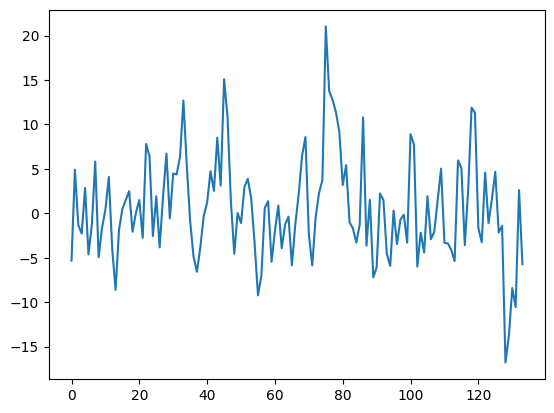

In [ ]:
plt.plot(residuals_ar)
plt.savefig('residuals_plot.png')

In [ ]:
n = 1
# get iid and AR residuals from relevant processes
# residuals_iid = np.stac   k([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar = np.zeros((len(gmsl_data), n))
for t in range(len(gmsl_data)):
    if t == 0:
        residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2)), n)
    else:
        residuals_ar[t, :] = θ_ar[-1] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2), n)


In [ ]:
# S_0, response_time, a, b, σ, ρ
# -2000,-2000,0.1,,-1,0.1


In [ ]:
# Seq = np.zeros(len(gmt_data))
# def sim_gmsl(S_0, gmta_data, response_time, a, b):
#     Seq = np.zeros(len(gmta_data))
#     S = np.zeros(len(gmta_data))
#     S[0] = S_0
        
#     for i in range(0,len(gmta_data)-1):
#         Seq[i] = a*gmta_data[i] + b
#         S[i+1] = S[i] + (Seq[i]-S[i])/response_time
    
#     return(S)
        

In [ ]:
# def gmsl_loglik(params, gmsl_data, gmta_data):
#     S_0, response_time, a, b, σ, ρ  = params  # unpack parameter vector
#     gmsl_sim = sim_gmsl(S_0, gmta_data, response_time, a, b)
#     residuals = (gmsl_data - gmsl_sim)
#     # ll = np.sum(norm.logpdf(gmsl_data, loc=y, scale=np.sqrt(σ**2+gmsl_error**2)))  # compute log-likelihood
#     T = len(gmsl_data)
#     ll = 0  # initialize log-likelihood counter
#     for t in range(len(residuals)):
#         if t == 0:
#             ll += norm.logpdf(residuals[0], loc=0, scale=np.sqrt(σ**2 / (1 - ρ**2)))
#         else:
#             resid_wn = residuals[t] - ρ * residuals[t-1]
#             ll += norm.logpdf(resid_wn, loc=0, scale=np.sqrt(σ**2))

#     return ll



In [ ]:
# lb = [-2000.0, 0.1, -1000.0,-1000.0,  0.1,  -0.99]
# ub = [100.0, 10000.0, 2000.0,2000.0,  2000.0,  0.99]
# # p0 = [-160, 208.0, 1290.0, 770.0, 0.5, 0.5]
# p0 = [10, 0, 1500, 770.0, 0.5, 0.5]

# optim_out = minimize(lambda params: -gmsl_loglik(np.array(params), np.array(gmsa_data['GMSL (mm)']), np.array(gmt_data['Anomaly (deg C)'])), p0, bounds=list(zip(lb, ub)))
# # , tol=0.0001
# # , tol=0.0001
# p_mle = np.round(optim_out.x)

# print(p_mle)
# # θ_ar = optim_out.minimizer
# θ_ar = optim_out.x

In [ ]:
# sim_out = sim_gmsl(p_mle[0], np.array(gmt_data['Anomaly (deg C)']), p_mle[1], p_mle[2], p_mle[3])
# sim_out = pd.Series(data = sim_out, index = gmt_data.index)

In [ ]:
q_boot_coefficient = np.zeros([len(dat['weather']),2])
for i in range(len(dat['weather'])):
    q_boot_coefficient[i,:] = 2 * dat['gauge'][i] - np.quantile(bootstrap_replicate[i,:], [0.95, 0.05])

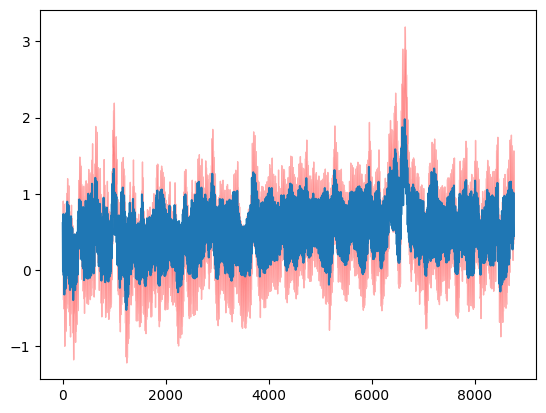

In [ ]:
plt.plot(dat['gauge'].index, dat['gauge'].values)
# plt.plot(x, λ, color = 'orange')
# plt.plot(dat['gauge'].index, means, color = 'red')
plt.fill_between(dat['gauge'].index, q_boot_coefficient[:,0], q_boot_coefficient[:,1], color='red', alpha=0.3, label = '90% Interval')
# plt.ylabel("Salamander Count")
# plt.xlabel("Percentage of Ground Cover (normalized)")
# plt.title("Salamander Count vs. Percent Ground Cover")
# plt.legend(['Data','Poisson Model','90% Interval' ])

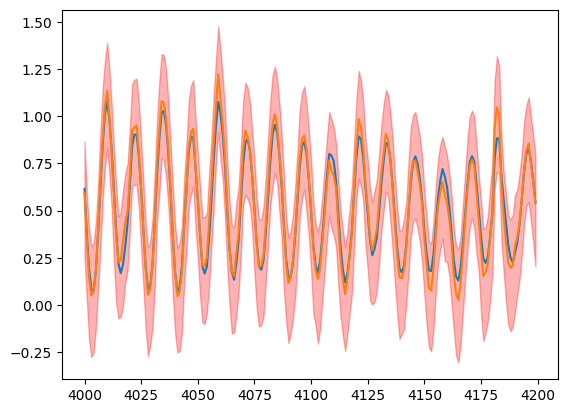

In [ ]:
s = 4000
e = 4200
plt.plot(dat['gauge'].index[s:e], dat['gauge'].values[s:e])
# plt.plot(x, λ, color = 'orange')
# plt.plot(dat['gauge'].index, means, color = 'red')
plt.fill_between(dat['gauge'].index[s:e], q_boot_coefficient[:,0][s:e], q_boot_coefficient[:,1][s:e], color='red', alpha=0.3, label = '90% Interval')
# plt.ylabel("Salamander Count")
# plt.xlabel("Percentage of Ground Cover (normalized)")
# plt.title("Salamander Count vs. Percent Ground Cover")
# plt.legend(['Data','Poisson Model','90% Interval' ])
plt.plot(dat['gauge'].index[s:e], bias_corrected[s:e])

In [ ]:
q_boot_coefficient[i,:] = 2 * dat['gauge'][i] - np.quantile(bootstrap_replicate[i,:], [0.95, 0.05])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
bias_corrected = np.zeros(len(dat['weather']))
for i in range(len(dat['weather'])):
    mean_boot = bootstrap_replicate[i,:].mean()
    bias = dat['gauge'][i] -  mean_boot
    bias_corrected[i] = dat['gauge'][i] + bias

In [ ]:
q_boot_coefficient = np.zeros([len(dat['weather']),2])
for i in range(len(dat['weather'])):
    q_boot_coefficient[i,:] = 2 * dat['gauge'][i] - np.quantile(bootstrap_replicate[i,:], [0.95, 0.05])

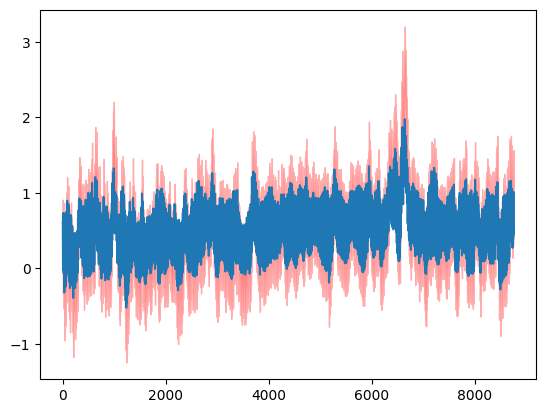

In [ ]:
plt.plot(dat['gauge'].index, dat['gauge'].values)
# plt.plot(x, λ, color = 'orange')
# plt.plot(dat['gauge'].index, means, color = 'red')
plt.fill_between(dat['gauge'].index, q_boot_coefficient[:,0], q_boot_coefficient[:,1], color='red', alpha=0.3, label = '90% Interval')
# plt.ylabel("Salamander Count")
# plt.xlabel("Percentage of Ground Cover (normalized)")
# plt.title("Salamander Count vs. Percent Ground Cover")
# plt.legend(['Data','Poisson Model','90% Interval' ])

In [ ]:
q_boot_coefficient[i,:] = 2 * dat['gauge'][i] - np.quantile(bootstrap_replicate[i,:], [0.95, 0.05])

In [ ]:
bias_corrected = np.zeros(len(dat['weather']))
for i in range(len(dat['weather'])):
    mean_boot = bootstrap_replicate[i,:].mean()
    bias = dat['gauge'][i] -  mean_boot
    bias_corrected[i] = dat['gauge'][i] + bias

In [ ]:
np.random.choice(range(n_blocks), m, replace=True).shape

(176,)

In [ ]:
# sim_out = sim_gmsl(p_mle[0], np.array(gmt_data['Anomaly (deg C)']), p_mle[1], p_mle[2], p_mle[3])
# sim_out = pd.Series(data = sim_out, index = gmt_data.index)

In [ ]:
# n = 1000
# # get iid and AR residuals from relevant processes
# # residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
# residuals_ar = np.zeros((len(gmsl_data), n))
# for t in range(len(gmsl_data)):
#     if t == 0:
#         residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2)), n)
#     else:
#         residuals_ar[t, :] = θ_ar[-2] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2), n)


In [ ]:
# iter % 25

In [ ]:
# optim_out = minimize(lambda params: -gmsl_loglik(np.array(params), np.array(gmsa_data['GMSL (mm)']), np.array(gmt_data['Anomaly (deg C)'])), p0, bounds=list(zip(lb, ub)))